In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
df=pd.read_csv("height-weight.csv")

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


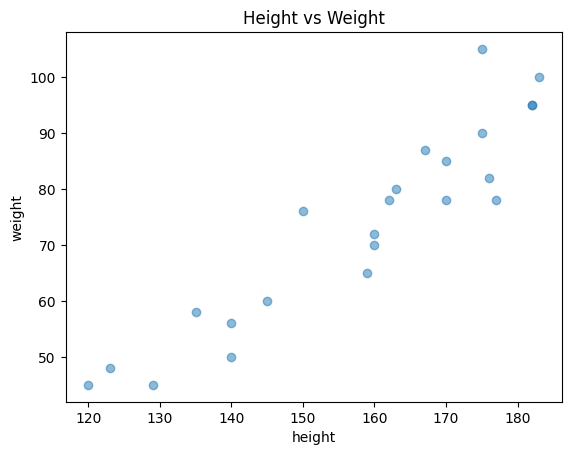

In [6]:
##scatter plot
plt.scatter(df['Height'],df['Weight'], alpha=0.5)
plt.title('Height vs Weight')
plt.xlabel('height')
plt.ylabel('weight')
plt.show()

In [7]:
#correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


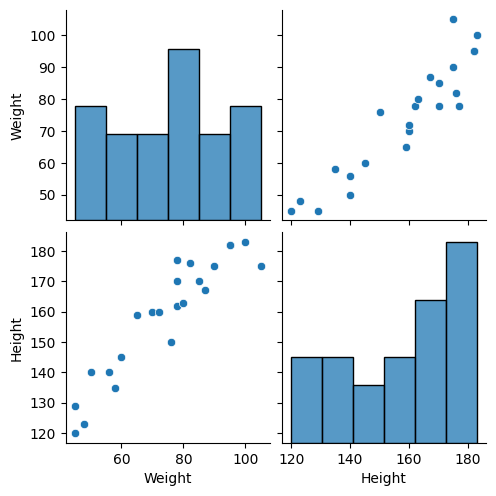

In [8]:
import seaborn as sns
sns.pairplot(df)

In [9]:
#dividing the features
x=df[['Height']] #note: your independent must be in 2D array or in dataframe format
y=df['Weight']

In [10]:
#train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
x_train.shape

(18, 1)

In [12]:
#standardization
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [13]:
x_train_scaled = scaler.fit_transform(x_train)

In [14]:
x_test_scaled = scaler.transform(x_test)

In [15]:
#appling simple linear regression ml algorithm
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [16]:
regression=model.fit(x_train_scaled,y_train)

In [17]:
regression

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
print("slope : ",regression.coef_)

slope :  [16.71556824]


In [21]:
print("intercept : ", regression.intercept_)

intercept :  74.27777777777777


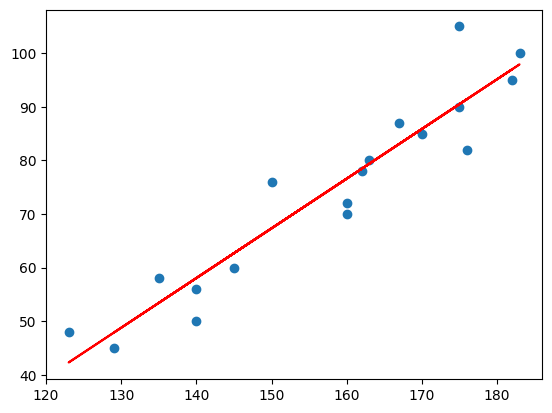

In [25]:
#plotting the training data best fit line
plt.scatter(x_train, y_train)
plt.plot(x_train, regression.predict(x_train_scaled), color='red')

## predicted test output:
predicted output= intercept + coef_(weights)

y_pred_test=74.277 + 16.71(x_test)

In [26]:
#prediction for the test data
y_pred=regression.predict(x_test_scaled)

In [29]:
#performance metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [31]:
mse=mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2_score=r2_score(y_test, y_pred)
print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)
print("accuracy :", r2_score)


mse :  83.23803021031195
mae :  8.078703941181502
rmse :  9.123487831433325
accuracy : 0.6981504561563971


In [33]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.7 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.5 MB 1.6 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/9.5 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/9.5 MB 581.9 kB/s eta 0:00:15
   ----- ---------------------------------- 1.3/9.5 MB 581.9 kB/s eta 0:00:15
   ----- ---------------------------------- 1.3/9.5 MB 581.9 kB/s eta 0:00:15
   ----- -----------

In [34]:
#ols technique of linear regression
import statsmodels.api as sm
model=sm.OLS(y_train, x_train_scaled).fit()
prediction = model.predict(x_test_scaled)
print(prediction)

[ 18.08296999  11.59164743 -34.77494229  22.71962896   1.39099769]


In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Weight   R-squared (uncentered):                   0.048
Model:                            OLS   Adj. R-squared (uncentered):             -0.008
Method:                 Least Squares   F-statistic:                             0.8558
Date:                Sat, 21 Mar 2026   Prob (F-statistic):                       0.368
Time:                        14:45:04   Log-Likelihood:                         -103.14
No. Observations:                  18   AIC:                                      208.3
Df Residuals:                      17   BIC:                                      209.2
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------